## Cyclistic bike-share analysis case study Step 4 - Analyze

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv(r"C:\Users\Gurunath Chavan\Desktop\LEARNING\GOOGLE DATA ANALYTICS\MOD 9\Case study 1\Dataset\cleaned_cyclistic_data.csv")

### Ride Length Comparison (Members vs Casual)

Average ride length (min):
 member_casual
casual    19.133336
member    11.952484
Name: ride_length, dtype: float64


C:\Users\Gurunath Chavan\AppData\Local\Temp\ipykernel_21968\158812689.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_ride_length.index, y=avg_ride_length.values, palette="viridis")


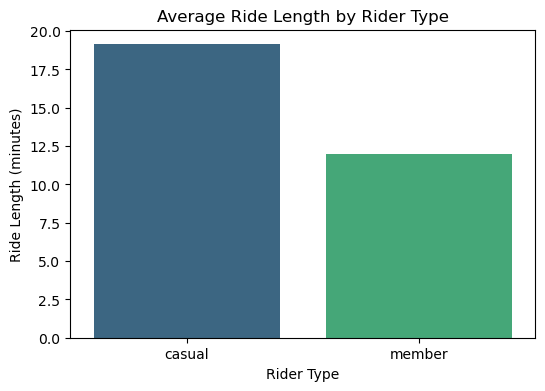

In [5]:
avg_ride_length = data.groupby("member_casual")["ride_length"].mean()
print("Average ride length (min):\n", avg_ride_length)

plt.figure(figsize=(6,4))
sns.barplot(x=avg_ride_length.index, y=avg_ride_length.values, palette="viridis")
plt.title("Average Ride Length by Rider Type")
plt.ylabel("Ride Length (minutes)")
plt.xlabel("Rider Type")
plt.show()

### Day of Week Usage

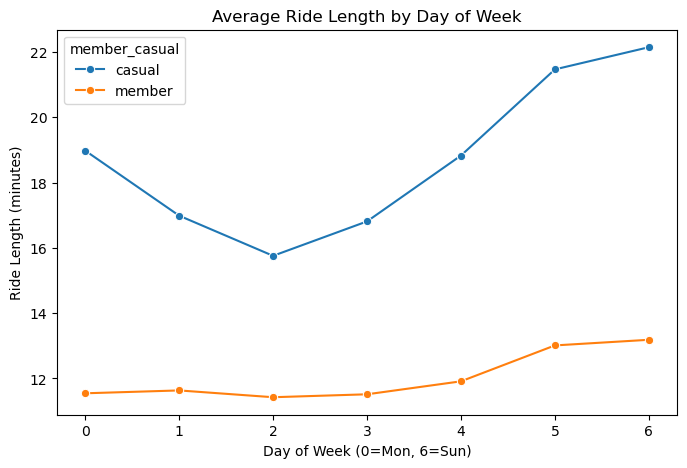

In [6]:
avg_by_day = data.groupby(["member_casual","day_of_week"])["ride_length"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=avg_by_day, x="day_of_week", y="ride_length", hue="member_casual", marker="o")
plt.title("Average Ride Length by Day of Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Ride Length (minutes)")
plt.show()

### Ride counts by day

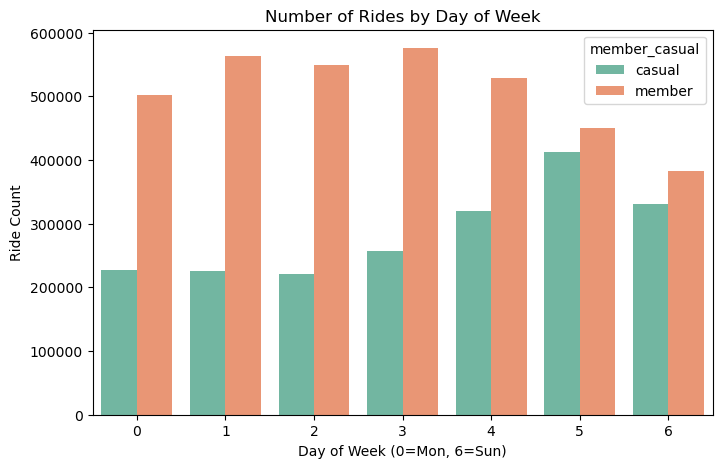

In [7]:
ride_counts = data.groupby(["member_casual","day_of_week"])["ride_id"].count().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=ride_counts, x="day_of_week", y="ride_id", hue="member_casual", palette="Set2")
plt.title("Number of Rides by Day of Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Ride Count")
plt.show()


### Seasonal Trends (Monthly Usage)

In [9]:
data["started_at"] = pd.to_datetime(data["started_at"], errors="coerce")
data = data.dropna(subset=["started_at"])

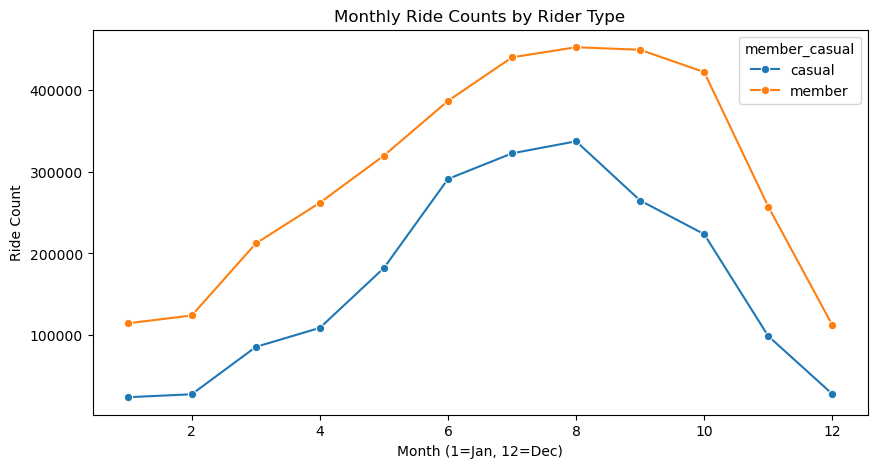

In [10]:
data["month"] = data["started_at"].dt.month
monthly_counts = data.groupby(["member_casual","month"])["ride_id"].count().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_counts, x="month", y="ride_id", hue="member_casual", marker="o")
plt.title("Monthly Ride Counts by Rider Type")
plt.xlabel("Month (1=Jan, 12=Dec)")
plt.ylabel("Ride Count")
plt.show()


### Station Usage (Top 10 start stations for casual vs members)

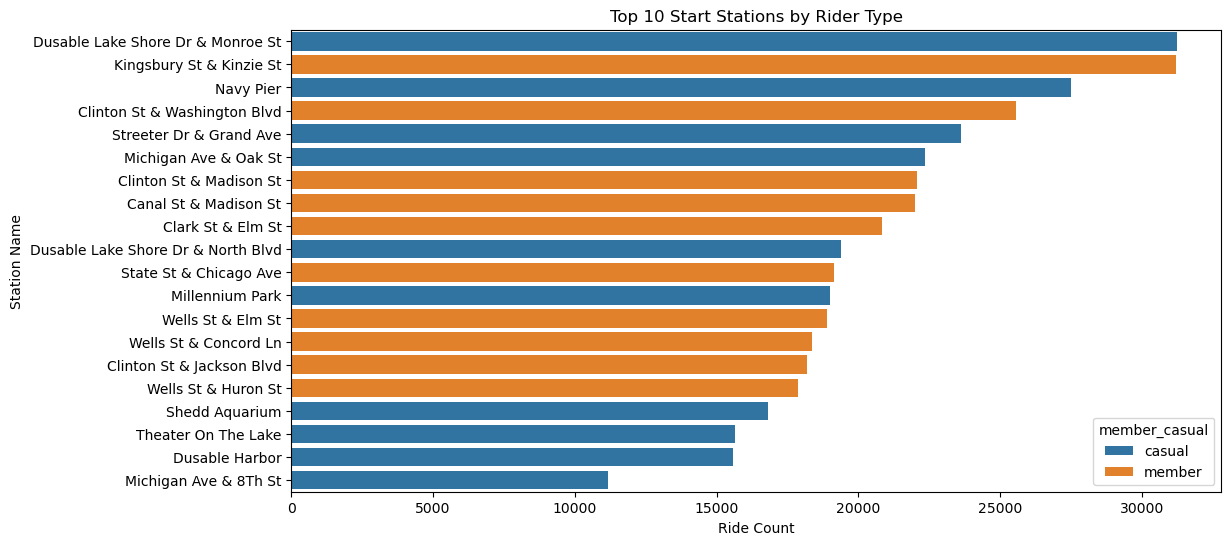

In [11]:
if "start_station_name" in data.columns:
    top_stations = data.groupby(["member_casual","start_station_name"])["ride_id"].count().reset_index()
    top_stations = top_stations.sort_values("ride_id", ascending=False).groupby("member_casual").head(10)

    plt.figure(figsize=(12,6))
    sns.barplot(data=top_stations, x="ride_id", y="start_station_name", hue="member_casual")
    plt.title("Top 10 Start Stations by Rider Type")
    plt.xlabel("Ride Count")
    plt.ylabel("Station Name")
    plt.show()
